In [1]:
""" Import libraries """

import LoadSaveFunctions as lsf
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, Data
from scipy.stats import t, linregress

In [2]:
""" Load Dataset """

data = lsf.load_excel_file()

print(data.head(5))

Selected file: /home/grominou/Documents/Git_Projects/LinearModels/test.xlsx
Excel file loaded successfully.
   d18Op  d18OpSD  d18Ow  d18OwSD
0   13.8      0.2   -7.3      0.3
1   12.9      0.5   -7.3      0.1
2   14.9      0.3   -5.6      0.1
3   14.7      0.1   -5.6      0.6
4   19.4      0.8   -1.8      0.7


In [4]:
""" Functions definition """

def york_regression_with_intervals(x, y, sigma_x, sigma_y, confidence=0.95):
    """
    Perform York regression (orthogonal distance regression) and compute confidence & prediction envelopes.
    
    Parameters:
    - x: array-like, δ18O (or other isotope) values for the x
    - y: array-like, δ18O (or other isotope) values for the y
    - sigma_x: array-like, uncertainties in the x values
    - sigma_y: array-like, uncertainties in the y values
    - confidence: float, confidence level for the intervals (default = 0.95)
    
    Returns:
    - slope, intercept, slope_err, intercept_err: regression parameters with uncertainties
    - x_fit, y_fit: fitted regression line
    - lower_conf, upper_conf: confidence interval bounds
    - lower_pred, upper_pred: prediction interval bounds
    """
    
    # Define the linear function for ODR
    def linear_func(B, x):
        return B[0] * x + B[1]

    # Set up ODR (York regression)
    data = Data(x, y, wd=1/sigma_x**2, we=1/sigma_y**2)
    model = Model(linear_func)
    odr = ODR(data, model, beta0=[1, 0])  # Initial guess: slope=1, intercept=0
    output = odr.run()
    output.pprint()

    # Extract parameters
    slope, intercept = output.beta
    slope_err, intercept_err = output.sd_beta

    # Compute residual standard deviation
    n = len(x)
    y_fit = slope * x + intercept
    residuals = y - y_fit
    S = np.sum(residuals**2)  # Residual sum of squares
    s_err = np.sqrt(S / (n - 2))  # Standard error of the estimate

    # Generate fit line
    x_fit = np.linspace(min(x) - 1, max(x) + 1, 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence and prediction intervals
    x_mean = np.mean(x)
    sum_x_squared = np.sum((x - x_mean)**2)
    t_value = t.ppf((1 + confidence) / 2, df=n - 2)  # Two-tailed t critical value

    # Confidence interval
    SE_conf = np.sqrt(s_err**2 * (1/n + (x_fit - x_mean)**2 / sum_x_squared))
    conf_margin = t_value * SE_conf
    lower_conf, upper_conf = y_fit - conf_margin, y_fit + conf_margin

    # Prediction interval
    SE_pred = np.sqrt(SE_conf**2 + s_err**2)
    pred_margin = t_value * SE_pred
    lower_pred, upper_pred = y_fit - pred_margin, y_fit + pred_margin

    return slope, intercept, slope_err, intercept_err, x_fit, y_fit, lower_conf, upper_conf, lower_pred, upper_pred, s_err

def predict_y_with_uncertainty(new_x, x_data, slope, intercept, s_err, confidence=0.95):
    """
    Predict y for a new x value with prediction uncertainty.

    Parameters:
    - new_x: scalar, the new x value to predict y for
    - x_data: array-like, original x data used for regression
    - slope, intercept: regression parameters from York fit
    - s_err: standard error of the estimate from York regression
    - confidence: confidence level (default: 0.95)

    Returns:
    - y_pred: predicted y value
    - pred_error: prediction error (half-width of the prediction interval)
    """

    n = len(x_data)
    x_mean = np.mean(x_data)
    sum_x_squared = np.sum((x_data - x_mean)**2)
    t_value = t.ppf((1 + confidence) / 2, df=n - 2)  # Critical t-value

    # Compute predicted y
    y_pred = slope * new_x + intercept

    # Standard error for prediction
    SE_pred = np.sqrt(s_err**2 * (1 + 1/n + (new_x - x_mean)**2 / sum_x_squared))

    # Prediction error (half-width of the prediction interval)
    pred_error = t_value * SE_pred

    return y_pred, pred_error, SE_pred


Beta: [  0.92451363 -20.80519516]
Beta Std Error: [0.07393826 1.25001402]
Beta Covariance: [[ 0.00046633 -0.00778982]
 [-0.00778982  0.13328536]]
Residual Variance: 11.723230921199471
Inverse Condition #: 0.0009062198841359368
Reason(s) for Halting:
  Sum of squares convergence
Slope: 0.925 ± 0.074
Intercept: -20.805 ± 1.250
Predicted Y for X = 15: -6.937 ± 2.430 (95% Prediction Interval)


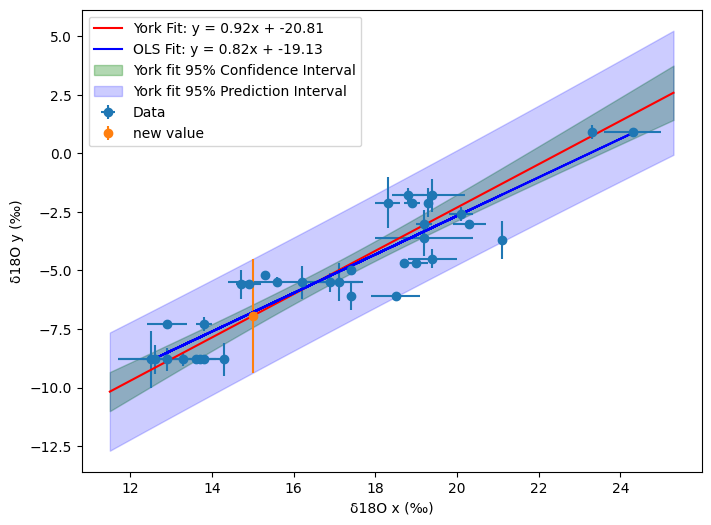

In [5]:
# Example usage

confidence = 0.95
results = york_regression_with_intervals(data['d18Op'], data['d18Ow'], data['d18OpSD'], data['d18OwSD'])
print(f"Slope: {results[0]:.3f} ± {results[2]:.3f}")
print(f"Intercept: {results[1]:.3f} ± {results[3]:.3f}")

# compute ols for comparison

res = linregress(data['d18Op'], data['d18Ow'])

# Predict a new Y value for an input X
new_x = 15  # Example new δ18O fluid value
y_pred, pred_error, SE_pred = predict_y_with_uncertainty(new_x, data['d18Op'], results[0], results[1], results[10])

print(f"Predicted Y for X = {new_x}: {y_pred:.3f} ± {pred_error:.3f} (95% Prediction Interval)")

# Plot the results
plt.figure(figsize=(8, 6))
plt.errorbar(data['d18Op'], data['d18Ow'], xerr=data['d18OpSD'], yerr=data['d18OwSD'], fmt='o', label="Data")
plt.errorbar(new_x, y_pred, yerr=pred_error, fmt='o', label="new value")
plt.plot(results[4], results[5], 'r-', label=f"York Fit: y = {results[0]:.2f}x + {results[1]:.2f}")
plt.plot(data['d18Op'], res.intercept + res.slope*data['d18Op'], 'b-', label=f"OLS Fit: y = {res.slope:.2f}x + {res.intercept:.2f}")
plt.fill_between(results[4], results[6], results[7], color='green', alpha=0.3, label=f"York fit {confidence*100:.0f}% Confidence Interval")
plt.fill_between(results[4], results[8], results[9], color='blue', alpha=0.2, label=f"York fit {confidence*100:.0f}% Prediction Interval")
plt.xlabel("δ18O x (‰)")
plt.ylabel("δ18O y (‰)")
plt.legend()
plt.show()